In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [97]:
data_dir = '/content/drive/MyDrive/Project/garbage_classification'

In [98]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)
class_names = train_ds.class_names
print("Classes:", class_names)

Found 2390 files belonging to 5 classes.
Using 1912 files for training.
Found 2390 files belonging to 5 classes.
Using 478 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic']


In [99]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [100]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train = np.concatenate([labels.numpy() for images, labels in train_ds], axis=0)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.1875776397515527), 1: np.float64(0.9583959899749374), 2: np.float64(1.1518072289156627), 3: np.float64(0.8153518123667377), 4: np.float64(0.9805128205128205)}


In [101]:
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [102]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.2247 - loss: 1.9247 - val_accuracy: 0.3996 - val_loss: 1.4003
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.4214 - loss: 1.3390 - val_accuracy: 0.5356 - val_loss: 1.1631
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.5184 - loss: 1.1143 - val_accuracy: 0.5565 - val_loss: 1.1060
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5575 - loss: 1.0617 - val_accuracy: 0.5921 - val_loss: 1.1367
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.6003 - loss: 1.0158 - val_accuracy: 0.6318 - val_loss: 1.0349
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6497 - loss: 0.8932 - val_accuracy: 0.5251 - val_loss: 1.1666
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.7215 - loss: 0.7330 - val_accuracy: 0.6297 - val_loss: 1.0314
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.7800 - loss: 0.6236 - val_accuracy: 0.6715 - v

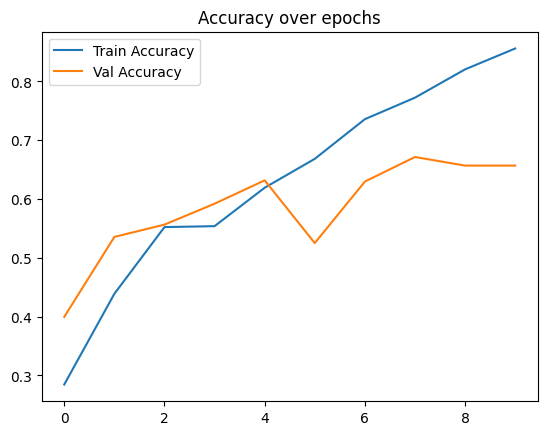

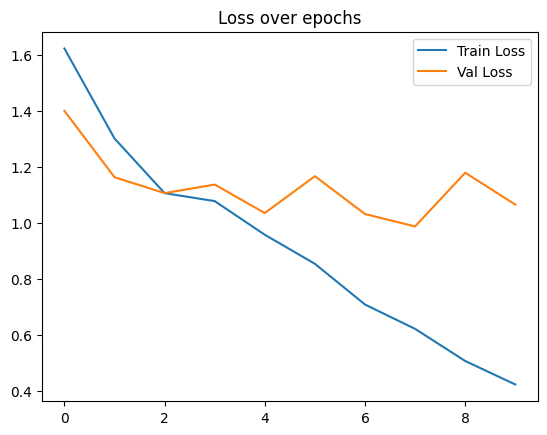

In [103]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy over epochs')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss over epochs')
plt.show()

In [104]:
import os

data_dir = '/content/drive/MyDrive/Project/garbage_classification'
for class_name in os.listdir(data_dir):
    path = os.path.join(data_dir, class_name)
    print(f"{class_name}: {len(os.listdir(path))} görüntü")


cardboard: 403 görüntü
plastic: 482 görüntü
paper: 594 görüntü
metal: 410 görüntü
glass: 501 görüntü


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
              precision    recall  f1-score   support

   cardboard       0.82      0.81      0.82        81
       glass       0.61      0.58      0.59       102
       metal       0.55      0.49      0.52        78
       paper       0.77      0.72      0.74       125
     plastic       0.53      0.66      0.59        92

    accuracy                           0.66       478
   macro avg       0.66      0.65      0.65     

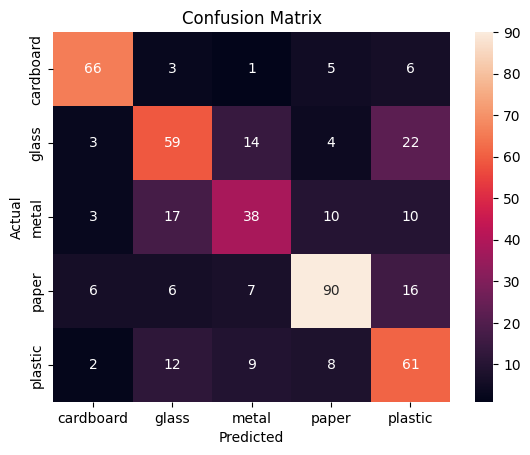

In [105]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

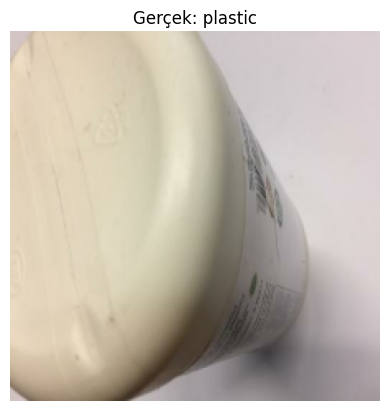

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
✅ Tahmin: glass
————————————————————————————————————————


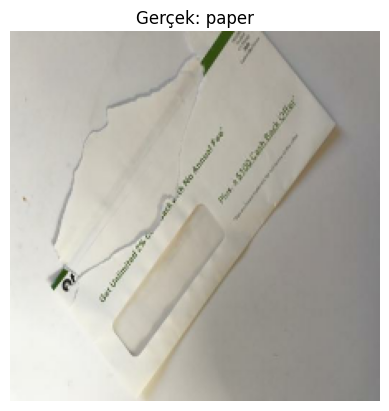

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
✅ Tahmin: paper
————————————————————————————————————————


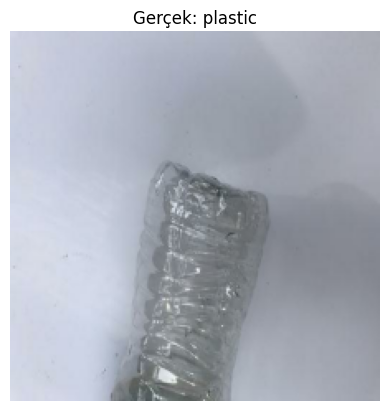

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
✅ Tahmin: plastic
————————————————————————————————————————


In [107]:
import matplotlib.pyplot as plt
import numpy as np

counter = 0
for images, labels in val_ds:
    for i in range(len(images)):
        if counter >= 3:
            break

        img_display = images[i].numpy().astype("uint8")
        true_label = labels[i].numpy()

        plt.imshow(img_display)
        plt.axis("off")
        plt.title(f"Gerçek: {class_names[true_label]}")
        plt.show()

        img_array = np.expand_dims(images[i].numpy(), axis=0)

        prediction = model.predict(img_array)
        predicted_class = class_names[np.argmax(prediction)]

        print(f"✅ Tahmin: {predicted_class}")
        print("—" * 40)

        counter += 1
    if counter >= 3:
        break


In [108]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [109]:
data_dir = '/content/drive/MyDrive/Project/garbage_classification'

img_size = (224, 224)
batch_size = 32

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Sınıflar:", class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(buffer_size=AUTOTUNE)


Found 2390 files belonging to 5 classes.
Using 1912 files for training.
Found 2390 files belonging to 5 classes.
Using 478 files for validation.
Sınıflar: ['cardboard', 'glass', 'metal', 'paper', 'plastic']


In [110]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(class_names), activation='softmax')(x)

model_vgg = Model(inputs=base_model.input, outputs=output)

In [111]:
model_vgg.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 294ms/step - accuracy: 0.2447 - loss: 5.0359 - val_accuracy: 0.4665 - val_loss: 1.7115
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 251ms/step - accuracy: 0.3678 - loss: 2.8543 - val_accuracy: 0.5858 - val_loss: 1.1738
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 238ms/step - accuracy: 0.4918 - loss: 1.9560 - val_accuracy: 0.6590 - val_loss: 0.9654
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - accuracy: 0.5494 - loss: 1.6774 - val_accuracy: 0.7050 - val_loss: 0.8310
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - accuracy: 0.5949 - loss: 1.3726 - val_accuracy: 0.7322 - val_loss: 0.7561
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 229ms/step - accuracy: 0.6162 - loss: 1.1607 - val_accuracy: 0.7364 - val_loss: 0.7145
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - accuracy: 0.6542 - loss: 1.0122 - val_accuracy: 0.7657 - val_loss: 0.6724
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step - accuracy: 0.6881 - loss: 0.8796 - val_accu

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
🔍 Classification Report:
              precision    recall  f1-score   support

   cardboard       0.90      0.90      0.90        81
       glass       0.74      0.72      0.73       102
       metal       0.74      0.72      0.73        78
       paper       0.84      0.90      0.86       125
     plastic       0.72      0.70      0.71        92

    accuracy                           0.79       478
   macro a

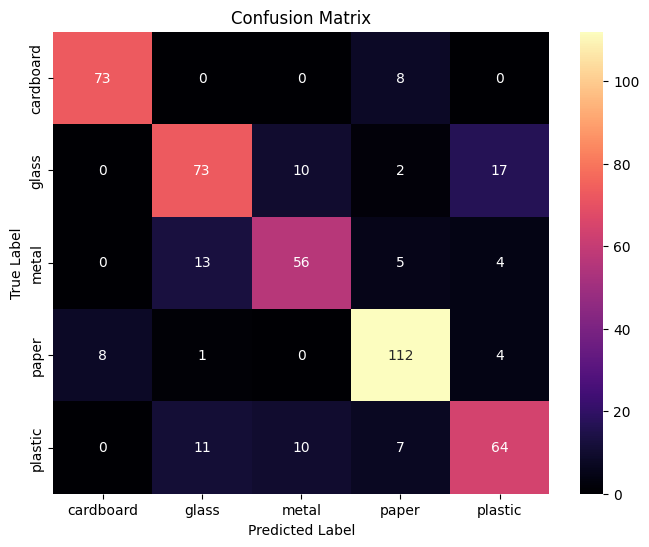

In [112]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_vgg.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))


print("🔍 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='magma',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


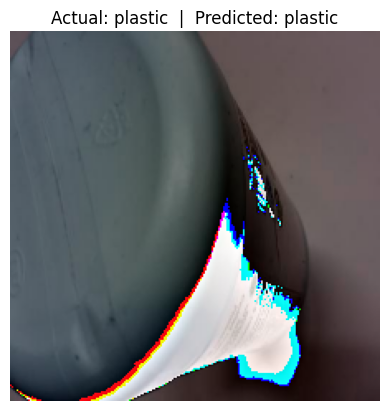

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


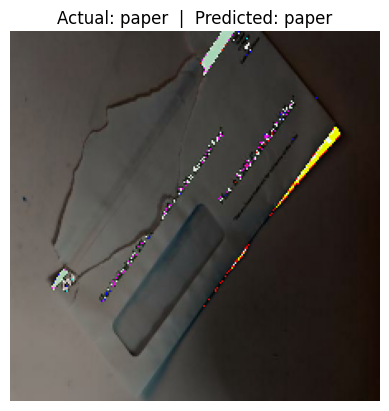

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


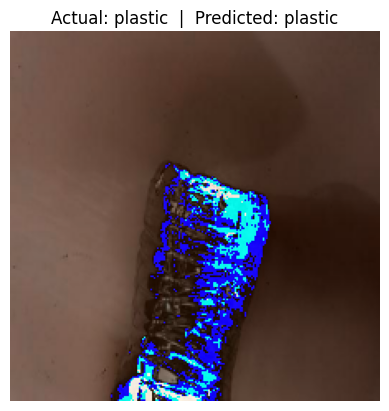

In [126]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in val_ds.take(1):
    for i in range(3):
        img = images[i].numpy().astype("uint8")
        true_label = class_names[labels[i].numpy()]

        img_array = np.expand_dims(images[i].numpy(), axis=0)
        prediction = model_vgg.predict(img_array)
        predicted_label = class_names[np.argmax(prediction)]


        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Actual: {true_label}  |  Predicted: {predicted_label}")
        plt.show()

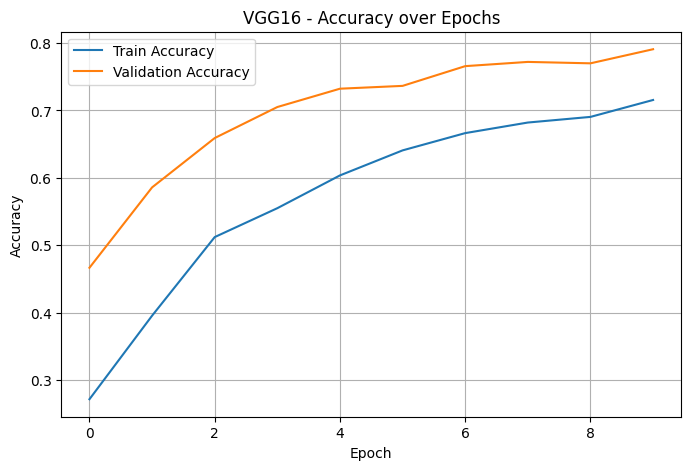

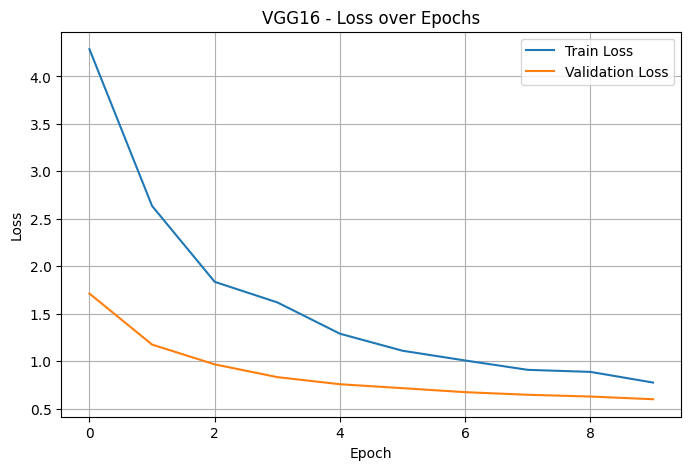

In [115]:
import matplotlib.pyplot as plt

train_acc = history_vgg.history['accuracy']
val_acc = history_vgg.history['val_accuracy']
train_loss = history_vgg.history['loss']
val_loss = history_vgg.history['val_loss']

plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGG16 - Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VGG16 - Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [127]:
# Tüm katmanları aç
base_model.trainable = True

# Sadece son 4 katman açık kalsın
fine_tune_at = len(base_model.layers) - 4

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False


In [118]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train = np.concatenate([labels.numpy() for images, labels in train_ds], axis=0)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

# (isteğe bağlı) manuel ayarlama
plastic_index   = class_names.index("plastic")
glass_index     = class_names.index("glass")
class_weights[plastic_index] *= 1.3
class_weights[glass_index]   *= 1.2


In [120]:
from tensorflow.keras.optimizers import Adam

model_vgg.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [121]:
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 15

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False


In [122]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))


In [123]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_finetune = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)


Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 34s 484ms/step - accuracy: 0.7222 - loss: 0.8522 - val_accuracy: 0.8033 - val_loss: 0.5781
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 473ms/step - accuracy: 0.7536 - loss: 0.7418 - val_accuracy: 0.8159 - val_loss: 0.5339
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 463ms/step - accuracy: 0.7790 - loss: 0.6558 - val_accuracy: 0.8368 - val_loss: 0.4911
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 43s 502ms/step - accuracy: 0.8257 - loss: 0.5357 - val_accuracy: 0.8536 - val_loss: 0.4541
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 482ms/step - accuracy: 0.8115 - loss: 0.5464 - val_accuracy: 0.8536 - val_loss: 0.4672
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 459ms/step - accuracy: 0.8512 - loss: 0.4524 - val_accuracy: 0.8556 - val_loss: 0.4623
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 454ms/step - accuracy: 0.8503 - loss: 0.4389 - val_accuracy: 0.8619 - val_loss: 0.4628
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 465ms/step - accuracy: 0.8647 - loss: 0.4037 - val_accu

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step
🔍 Classification Report:
              precision    recall  f1-score   support

   cardboard       0.90      0.93      0.91        81
       glass       0.89      0.83      0.86       102
       metal       0.81      0.91      0.86        78
       paper       0.92      0.90      0.91       125
     plastic       0.83      0.80      0.82        92

    accuracy                           0.87       478
   macro a

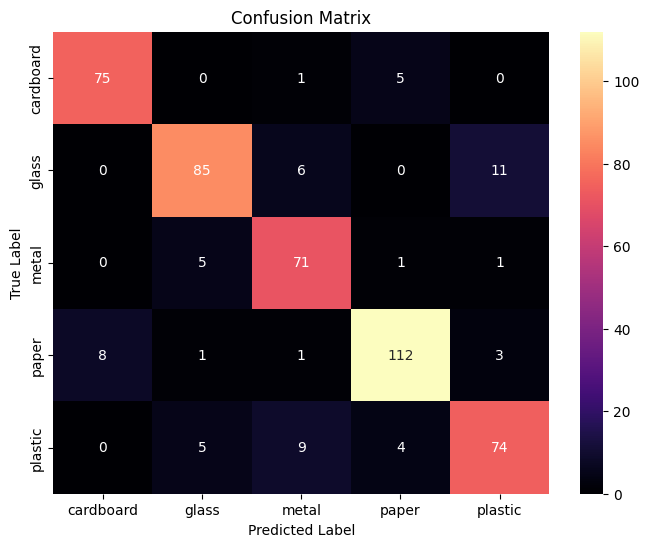

In [124]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Doğrulama setinden tahmin ve gerçek etiketler
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_vgg.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Sınıf adları daha önce tanımlanmış olmalı
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='magma',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step


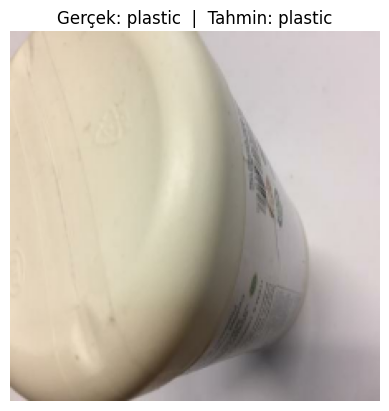

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


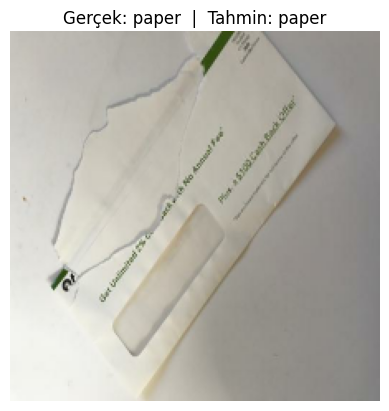

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


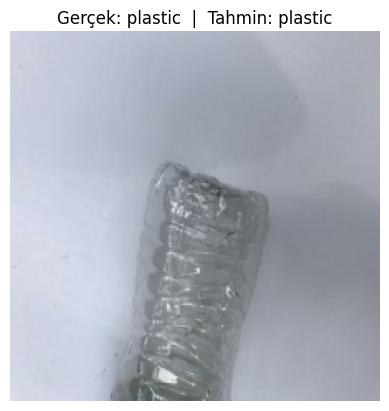

In [125]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.applications.vgg16 import preprocess_input

counter = 0
for images, labels in val_ds:
    for i in range(len(images)):
        if counter >= 3:
            break

        img_processed = images[i].numpy()

        # VGG16 preprocessing’i tersine çevir: (çünkü mean-subtraction yapıyor)
        img_display = img_processed.copy()
        img_display[..., 0] += 103.939  # B
        img_display[..., 1] += 116.779  # G
        img_display[..., 2] += 123.68   # R
        img_display = img_display[..., ::-1]  # BGR -> RGB
        img_display = np.clip(img_display, 0, 255).astype("uint8")

        true_label = class_names[labels[i].numpy()]
        img_array = np.expand_dims(img_processed, axis=0)

        prediction = model_vgg.predict(img_array)
        predicted_label = class_names[np.argmax(prediction)]

        plt.imshow(img_display)
        plt.axis("off")
        plt.title(f"Gerçek: {true_label}  |  Tahmin: {predicted_label}")
        plt.show()

        counter += 1
    if counter >= 3:
        break
